Import data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
from google.colab import drive
import matplotlib.ticker as ticker

In [ ]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
vd_df = pd.read_excel('./ViralDynamicsData_Publication.xlsx')

# Keep only treated individuals and sort for piecewise simulation
treated_df = vd_df[vd_df["treatment_cov"] == 1].copy()
treated_df = treated_df.sort_values(["ID", "time"])
# Load parameter tables
params_df_A1 = pd.read_csv("./estimatedIndividualParameters_A1.txt", sep=',')
params_df_A2 = pd.read_csv("./estimatedIndividualParameters_A2.txt", sep=',')
params_df_A3 = pd.read_csv("./estimatedIndividualParameters_A3.txt", sep=',')
params_df_A4T = pd.read_csv("./estimatedIndividualParameters_A4T.txt", sep=',')

In [ ]:
treated_df = vd_df[vd_df["treatment_cov"] == 1].copy()
treated_df = treated_df.sort_values(["ID", "time"])

In [ ]:
treated_patients = vd_df[vd_df['treatment'] == 1]['ID'].unique()

Simulate PK model with different rate parameter values ranging from 0.25x to 4x and output absolute epsilon values from target compartment A3 to create heatmap

In [ ]:

PK_CONSTANTS = {
   "A1": {"MolMass": 602.58, "Volume": 3690},
   "A2": {"MolMass": 442.32, "Volume": 30446.12},
   "A3": {"MolMass": 291.26, "Volume": 924.6},
   "A4T": {"MolMass": 531.2, "Volume": 1000000}
}

PD_PARAMS = {
   "Emax": 0.99,
   "Hill": 1,
   "c": 15,
   "k": 4,
   "F": 1_000_000
}

# Fixed PK Parameters
FIXED_PK = {
    "k12":22.525296,
    "k23":0.6,
    "kcl1":0.000864,
    "kcl2":9.6,
    "kcl3":6,
    "kcl4":1.0824,
    "k1pt":319.2,
    "k1tp":3.12,
    "k2pt":10.32,
    "k2tp":0.01296,
    "k3tp":0.036,
    "k3pt":1.08,
    "k34":6
}

In [ ]:
# 1. ODE System & Simulation
def pk_model_full_override(t, y, p_overrides):
    """
    ODE system that accepts dynamic overrides for all 13 target sensitivity parameters.
    """
    A1, A1T, A2, A2T, A3, A3T, A4T = y

    ddt_A1 = p_overrides['k1tp']*A1T - (p_overrides['k1pt'] + p_overrides['k12'] + p_overrides['kcl1'])*A1
    ddt_A1T = p_overrides['k1pt']*A1 - p_overrides['k1tp']*A1T - p_overrides['k12']*A1T
    ddt_A2 = p_overrides['k12']*A1 + p_overrides['k2tp']*A2T - (p_overrides['k2pt'] + p_overrides['kcl2'] + p_overrides['k23'])*A2
    ddt_A2T = p_overrides['k2pt']*A2 + p_overrides['k12']*A1T - p_overrides['k23']*A2T - p_overrides['k2tp']*A2T
    ddt_A3 = p_overrides['k3tp']*A3T - (p_overrides['kcl3'] + p_overrides['k3pt'])*A3 + p_overrides['k23']*A2
    ddt_A3T = -p_overrides['k3tp']*A3T + p_overrides['k23']*A2T + p_overrides['k3pt']*A3 - p_overrides['k34']*A3T
    ddt_A4T = p_overrides['k34']*A3T - p_overrides['kcl4']*A4T

    return [ddt_A1, ddt_A1T, ddt_A2, ddt_A2T, ddt_A3, ddt_A3T, ddt_A4T]

In [ ]:
def simulate_regimen_full_override(patient_id, params, p_overrides):
    ic50_a3 = params[params['id'] == patient_id]['IC50_mode'].values[0]

    # 5-day regimen schedule
    schedule = [(0.0, 200), (1.0, 100), (2.0, 100), (3.0, 100), (4.0, 100)]

    y0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
    t_out, y_out = [], []
    current_time = 0.0

    for t_event, dose_mg in schedule:
        y0[0] += dose_mg * 1_000_000
        next_time = t_event + 1.0

        sol = solve_ivp(
            fun=pk_model_full_override, t_span=(current_time, next_time), y0=y0,
            t_eval=np.linspace(current_time, next_time, 100),
            args=(p_overrides,), method='LSODA'
        )
        t_out.append(sol.t[:-1])
        y_out.append(sol.y[:, :-1])
        y0 = sol.y[:, -1]
        current_time = next_time

    # Evaluate 5-day window
    t_sim = np.concatenate(t_out)
    y_sim = np.concatenate(y_out, axis=1)

    # Calculate Epsilon for A4T (A4T is at index 6)
    cc = y_sim[6] / (PK_CONSTANTS["A4T"]["Volume"] * PK_CONSTANTS["A4T"]["MolMass"])
    eps_a4t = PD_PARAMS["Emax"] * (cc**PD_PARAMS["Hill"]) / ((cc**PD_PARAMS["Hill"]) + (ic50_a3**PD_PARAMS["Hill"]))

    mean_efficacy = np.trapz(eps_a4t, t_sim) / 5.0
    return mean_efficacy

In [ ]:
# 2. 1D Parameter Sweep & Absolute Efficacy Heatmap
def calculate_absolute_efficacy_sensitivity(patient_id_array, params):

    target_params = [
        'k12', 'k23', 'kcl1', 'kcl2', 'kcl3', 'kcl4',
        'k1pt', 'k1tp', 'k2pt', 'k2tp', 'k3tp', 'k3pt', 'k34'
    ]

    scales = np.array([0.25, 0.50, 0.75, 1.00, 1.50, 2.00, 3.00, 4.00])

    results_matrix = np.zeros((len(scales), len(target_params)))

    print(f"Executing 1D Parameter Sweep (Absolute Efficacy) across {len(patient_id_array)} patients...")

    # Baseline
    baseline_overrides = {p: FIXED_PK[p] for p in target_params}
    base_epsilons = [simulate_regimen_full_override(pid, params, baseline_overrides) for pid in patient_id_array]
    e_0 = np.mean(base_epsilons)

    baseline_idx = np.where(scales == 1.00)[0][0]
    results_matrix[baseline_idx, :] = e_0

    # Sweep
    for col_idx, param_name in enumerate(target_params):
        p_0 = FIXED_PK[param_name]

        for row_idx, scale in enumerate(scales):
            if scale == 1.00:
                continue

            current_overrides = baseline_overrides.copy()
            current_overrides[param_name] = p_0 * scale

            pt_epsilons = [
                simulate_regimen_full_override(pid, params, current_overrides)
                for pid in patient_id_array
            ]
            results_matrix[row_idx, col_idx] = np.mean(pt_epsilons)

    TINY_SIZE = 6
    SMALL_SIZE = 8
    MEDIUM_SIZE = 10
    BIGGER_SIZE = 12

    plt.rcParams.update({
        'font.size': SMALL_SIZE,
        'axes.labelsize': SMALL_SIZE,
        'xtick.labelsize': SMALL_SIZE,
        'ytick.labelsize': SMALL_SIZE,
        'axes.titlesize': MEDIUM_SIZE,
        'figure.titlesize': MEDIUM_SIZE
    })

    y_labels = [f"{s:.2f}" for s in scales]

    df_heatmap = pd.DataFrame(
        np.flipud(results_matrix),
        index=y_labels[::-1],
        columns=target_params
    )

    fig, ax = plt.subplots(figsize=(7.0, 3.5), dpi=300)

    hm = sns.heatmap(
        df_heatmap,
        annot=True,
        fmt=".2f",
        cmap="magma",
        annot_kws={"size": TINY_SIZE},
        cbar_kws={
            'label': r'Average Efficacy ($\bar{\epsilon}_{A4T}$)'
        },
        linewidths=0.4,
        linecolor='black',
        ax=ax
    )

    ax.set_xlabel(r"PK Parameter", fontsize=SMALL_SIZE)
    ax.set_ylabel(r"Scaling Factor", fontsize=SMALL_SIZE)

    plt.xticks(rotation=45, ha='right')

    cbar = hm.collections[0].colorbar
    cbar.ax.tick_params(labelsize=TINY_SIZE)
    cbar.set_label(
        r'Average Efficacy ($\bar{\epsilon}_{A4T}$)',
        fontsize=SMALL_SIZE
    )

    plt.tight_layout(pad=0.4)
    plt.show()

    plt.rcdefaults()

    return df_heatmap

Executing 1D Parameter Sweep (Absolute Efficacy) across 67 patients...


/tmp/ipykernel_4878/3033607487.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean_efficacy = np.trapz(eps_a4t, t_sim) / 5.0


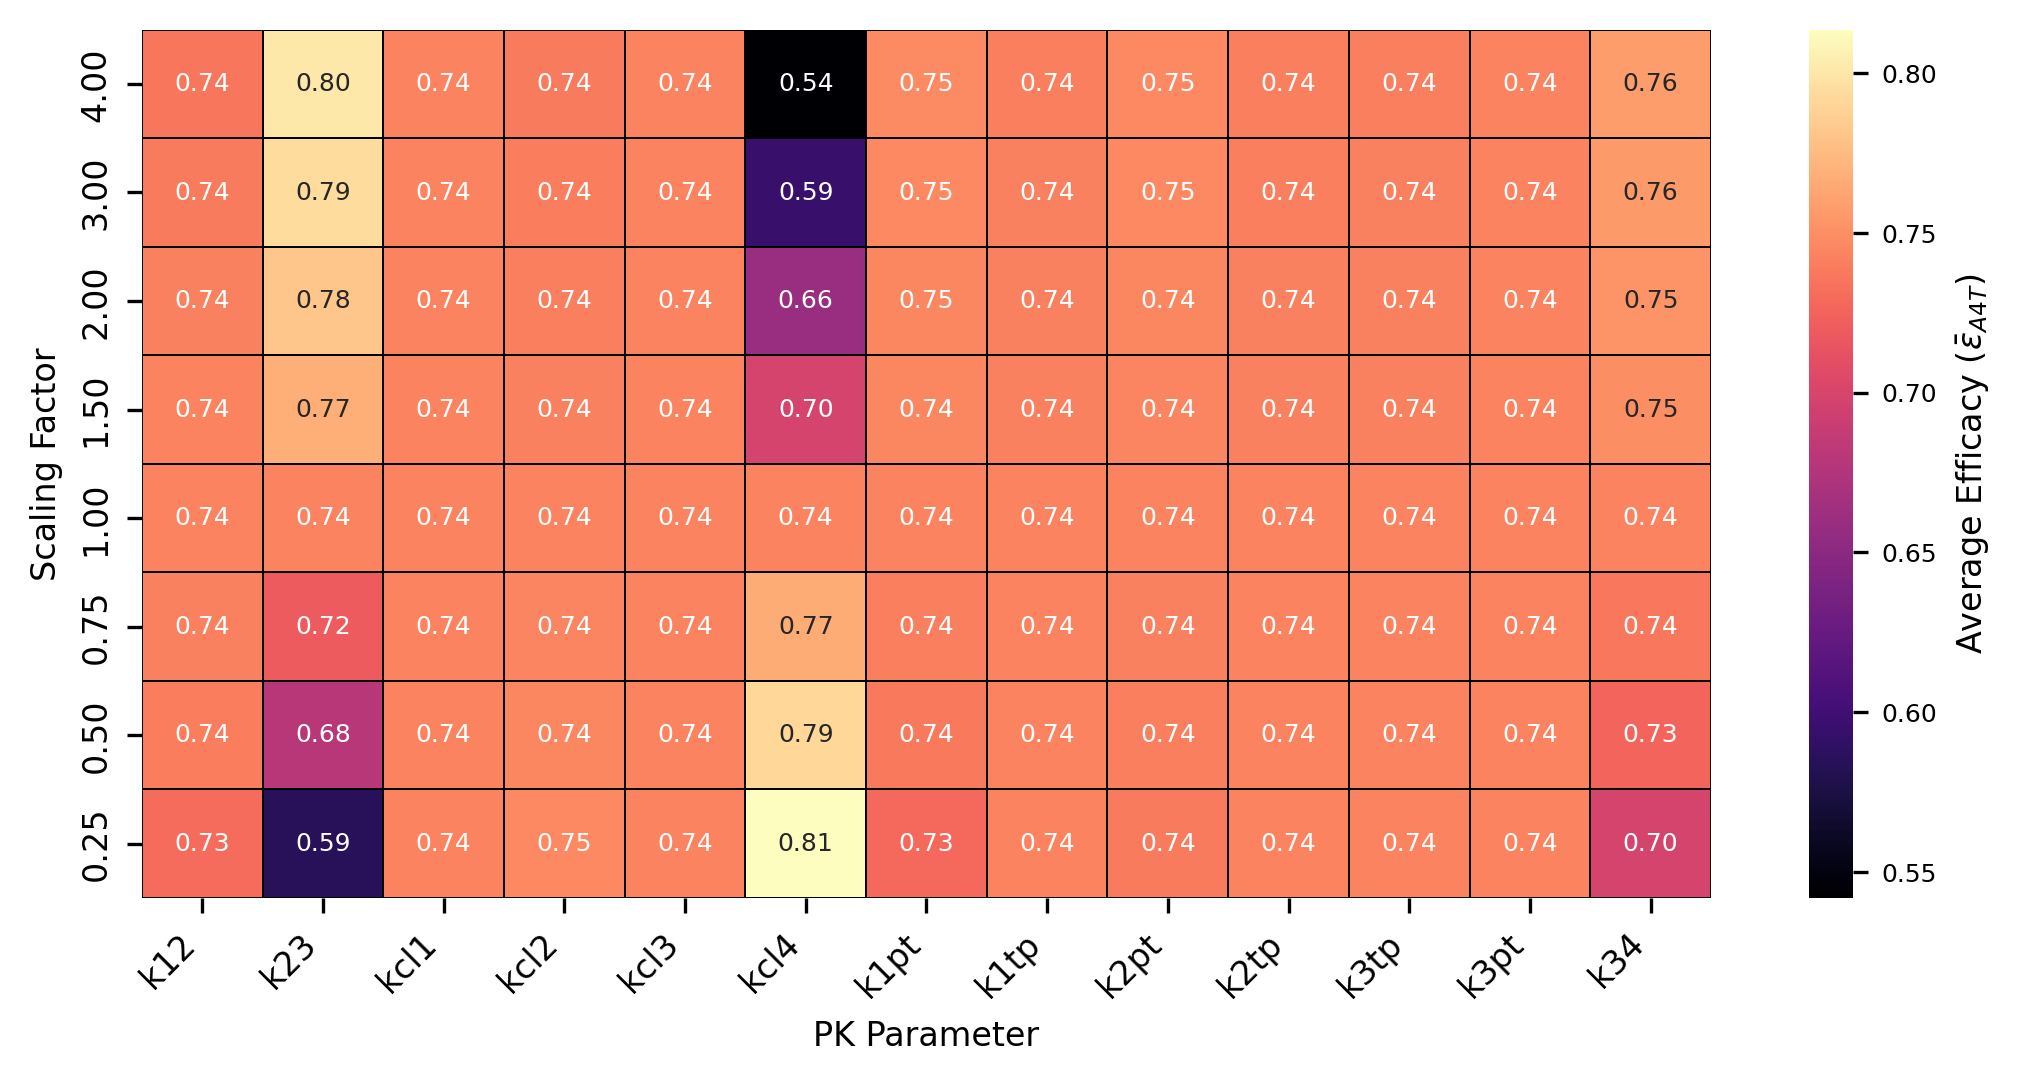

In [ ]:
heatmap_abs_eff_df = calculate_absolute_efficacy_sensitivity(treated_patients, params_df_A4T)

Heatmap: adjusting each rate parameter in the PK model from 0.25x to 4x and visualize difference in mean viral load log reduction in placebo vs treatment arm 5 days after first drug administration

In [ ]:
# 2. Parameter-Overridden ODE System
def viral_dynamic_model_override(t, y, target_cpt, params, dynamic_inputs, pk_overrides):
    """
    Combined PK/PD and Viral Dynamics ODE system accepting full parameter overrides
    for sensitivity profiling.
    """
    A1, A1T, A2, A2T, A3, A3T, A4T, T, R, E, I, V = y

    treatment = dynamic_inputs['treatment']
    beta, pi, rho, phi, delta, m, tau, IC50 = params['beta'], params['pi'], params['rho'], params['phi'], params['delta'], params['m'], params['tau'], params['IC50']

    ddt_A1 = pk_overrides['k1tp']*A1T - (pk_overrides['k1pt'] + pk_overrides['k12'] + pk_overrides['kcl1'])*A1
    ddt_A1T = pk_overrides['k1pt']*A1 - pk_overrides['k1tp']*A1T - pk_overrides['k12']*A1T
    ddt_A2 = pk_overrides['k12']*A1 + pk_overrides['k2tp']*A2T - (pk_overrides['k2pt'] + pk_overrides['kcl2'] + pk_overrides['k23'])*A2
    ddt_A2T = pk_overrides['k2pt']*A2 + pk_overrides['k12']*A1T - pk_overrides['k23']*A2T - pk_overrides['k2tp']*A2T
    ddt_A3 = pk_overrides['k3tp']*A3T - (pk_overrides['kcl3'] + pk_overrides['k3pt'])*A3 + pk_overrides['k23']*A2
    ddt_A3T = -pk_overrides['k3tp']*A3T + pk_overrides['k23']*A2T + pk_overrides['k3pt']*A3 - pk_overrides['k34']*A3T
    ddt_A4T = pk_overrides['k34']*A3T - pk_overrides['kcl4']*A4T

    # --- PD Layer ---
    Cc = 0
    if target_cpt == "A1":
        Cc = A1 / (PK_CONSTANTS["A1"]["Volume"] * PK_CONSTANTS["A1"]["MolMass"])
    elif target_cpt == "A2":
        Cc = A2 / (PK_CONSTANTS["A2"]["Volume"] * PK_CONSTANTS["A2"]["MolMass"])
    elif target_cpt == "A3":
        Cc = A3 / (PK_CONSTANTS["A3"]["Volume"] * PK_CONSTANTS["A3"]["MolMass"])
    elif target_cpt == "A4T":
        Cc = A4T / (PK_CONSTANTS["A4T"]["Volume"] * PK_CONSTANTS["A4T"]["MolMass"])

    epsilon = 0
    if treatment != 0 and Cc > 0:
        epsilon = PD_PARAMS['Emax'] * (Cc**PD_PARAMS['Hill']) / ((Cc**PD_PARAMS['Hill']) + (IC50**PD_PARAMS['Hill']))

    # --- Viral Dynamics Layer ---
    eps = m if t > tau else 0
    ddt_T = -beta * T * V - phi * I * T + rho * R
    ddt_R = phi * I * T - rho * R
    ddt_E = beta * T * V - PD_PARAMS['k'] * E
    ddt_I = PD_PARAMS['k'] * E - delta * I - eps * I

    if I >= 1:
        temp = pi * (1 - epsilon) * I - PD_PARAMS['c'] * V
    else:
        temp = -PD_PARAMS['c'] * V
    ddt_V = temp

    return [ddt_A1, ddt_A1T, ddt_A2, ddt_A2T, ddt_A3, ddt_A3T, ddt_A4T, ddt_T, ddt_R, ddt_E, ddt_I, ddt_V]

In [ ]:
# 3. Piecewise Simulation Engine
def simulate_patient_sens(patient_id, target_cpt, data_df, param_df, pk_overrides, force_treatment_state=None):
    """
    Simulates a single patient profile with strict PK parameter overrides.
    Returns the absolute reduction in log10 viral load from Day 0 to Day 5.
    """
    p_row = param_df[param_df['id'] == patient_id].iloc[0]
    params = {
        'beta': 10 ** p_row['log10beta_mode'], 'pi': 10 ** p_row['log10pi_mode'],
        'rho': 10 ** p_row['log10rho_mode'], 'phi': 10 ** p_row['log10phi_mode'],
        'delta': p_row['delta_mode'], 'm': p_row['m_mode'], 'tau': p_row['tau_mode'],
        'tzero': p_row['tzero_mode'], 'Vzero': p_row['Vzero_mode'], 'IC50': p_row['IC50_mode']
    }

    pt_data = data_df[data_df['ID'] == patient_id].sort_values(by='time').copy()

    y0 = [0, 0, 0, 0, 0, 0, 0, 1e7, 0, 0, 0, params['Vzero']]
    t_start = -params['tzero']

    t_out, y_out = [], []
    current_time = t_start
    first_record = pt_data.iloc[0]

    initial_treatment = first_record['treatment'] if force_treatment_state is None else force_treatment_state

    active_inputs = {
        'treatment': initial_treatment
    }

    # Time of first administration defines 'Day 0'
    doses = pt_data[pt_data['Amnt_mg'] > 0]
    t_day_zero = doses['time'].min() if not doses.empty else pt_data['time'].min()

    for idx, row in pt_data.iterrows():
        t_event = row['time']
        if t_event > current_time:
            t_eval = np.linspace(current_time, t_event, 30)
            sol = solve_ivp(
                fun=viral_dynamic_model_override, t_span=(current_time, t_event), y0=y0,
                t_eval=t_eval, args=(target_cpt, params, active_inputs, pk_overrides),
                method='LSODA', max_step=0.2
            )
            t_out.append(sol.t)
            y_out.append(sol.y)
            y0 = sol.y[:, -1]
            current_time = t_event

        dose_mg = row['Amnt_mg']
        if pd.notna(dose_mg) and dose_mg > 0 and active_inputs['treatment'] == 1:
            y0[0] += dose_mg * PD_PARAMS['F']

        if force_treatment_state is None and pd.notna(row['treatment']):
            active_inputs['treatment'] = row['treatment']

    # Ensure simulation reaches at least Day 5 relative to first dose
    t_final = max(current_time + 1.0, t_day_zero + 6.0)
    sol = solve_ivp(
        fun=viral_dynamic_model_override, t_span=(current_time, t_final), y0=y0,
        t_eval=np.linspace(current_time, t_final, 100),
        args=(target_cpt, params, active_inputs, pk_overrides), method='LSODA'
    )
    t_out.append(sol.t)
    y_out.append(sol.y)

    t_sim = np.concatenate(t_out)
    y_sim = np.concatenate(y_out, axis=1)

    # Extract raw viral load from index 11 (V is the 12th state)
    v_raw = y_sim[11, :]

    # --- LLOQ IMPUTATION LOGIC ---
    v_imputed = np.where(v_raw < 200.0, 100.0, v_raw)

    log10v_sim = np.log10(v_imputed)

    # Calculate absolute drop from exactly Day 0 to Day 5
    log_v_day0 = np.interp(t_day_zero, t_sim, log10v_sim)
    log_v_day5 = np.interp(t_day_zero + 5.0, t_sim, log10v_sim)

    vl_reduction = log_v_day0 - log_v_day5

    return vl_reduction

In [ ]:
# 4. Global Sensitivity Analysis Orchestrator
def calculate_viral_load_absolute_sensitivity(patient_id_array, data_df, param_df):

    target_params = [
        'k12', 'k23', 'kcl1', 'kcl2', 'kcl3', 'kcl4',
        'k1pt', 'k1tp', 'k2pt', 'k2tp', 'k3tp', 'k3pt', 'k34'
    ]
    scales = np.array([0.25, 0.50, 0.75, 1.00, 1.50, 2.00, 3.00, 4.00])

    results_matrix = np.zeros((len(scales), len(target_params)))

    print(f"Initiating global viral load absolute difference analysis for {len(patient_id_array)} profiles...")

    # Baseline
    baseline_pk = FIXED_PK.copy()
    base_control = [
        simulate_patient_sens(pid, "A4T", data_df, param_df, baseline_pk, force_treatment_state=0)
        for pid in patient_id_array
    ]
    base_treated = [
        simulate_patient_sens(pid, "A4T", data_df, param_df, baseline_pk, force_treatment_state=1)
        for pid in patient_id_array
    ]

    Y_0 = np.mean(base_treated) - np.mean(base_control)

    baseline_idx = list(scales).index(1.00)
    results_matrix[baseline_idx, :] = Y_0

    # Sweep
    for col_idx, p_name in enumerate(target_params):
        p_base_val = FIXED_PK[p_name]
        print(f"Profiling parameter trajectory for: {p_name}...")

        for row_idx, scale in enumerate(scales):
            if scale == 1.00:
                continue

            perturbed_pk = FIXED_PK.copy()
            perturbed_pk[p_name] = p_base_val * scale

            red_control = [
                simulate_patient_sens(pid, "A4T", data_df, param_df, perturbed_pk, force_treatment_state=0)
                for pid in patient_id_array
            ]
            red_treated = [
                simulate_patient_sens(pid, "A4T", data_df, param_df, perturbed_pk, force_treatment_state=1)
                for pid in patient_id_array
            ]

            results_matrix[row_idx, col_idx] = np.mean(red_treated) - np.mean(red_control)

    TINY_SIZE = 6
    SMALL_SIZE = 8
    MEDIUM_SIZE = 10
    BIGGER_SIZE = 12

    plt.rcParams.update({
        'font.size': SMALL_SIZE,
        'axes.labelsize': SMALL_SIZE,
        'xtick.labelsize': SMALL_SIZE,
        'ytick.labelsize': SMALL_SIZE,
        'axes.titlesize': MEDIUM_SIZE,
        'figure.titlesize': MEDIUM_SIZE
    })

    y_ticks_labels = [f"{s:.2f}" for s in scales]

    df_heatmap = pd.DataFrame(
        np.flipud(results_matrix),
        index=y_ticks_labels[::-1],
        columns=target_params
    )

    fig, ax = plt.subplots(figsize=(7.0, 3.5), dpi=300)

    hm = sns.heatmap(
        df_heatmap,
        annot=True,
        fmt=".2f",
        cmap="magma",
        annot_kws={"size": TINY_SIZE},
        linewidths=0.4,
        linecolor='black',
        cbar_kws={'label': r'Diff in Mean $Log_{10}$ VL Reduction'},
        ax=ax
    )

    ax.set_xlabel("PK Parameter", fontsize=SMALL_SIZE)
    ax.set_ylabel("Scaling Factor", fontsize=SMALL_SIZE)

    plt.xticks(rotation=45, ha='right')

    cbar = hm.collections[0].colorbar
    cbar.ax.tick_params(labelsize=TINY_SIZE)
    cbar.set_label(
        r'Diff in Mean $Log_{10}$ VL Reduction',
        fontsize=SMALL_SIZE
    )

    plt.tight_layout(pad=0.4)
    plt.show()

    plt.rcdefaults()

    return df_heatmap

In [ ]:

# 1. Isolate the TREATED arm data specifically for the Platcov study
treated_platcov_df = vd_df[(vd_df["Study"] == "Platcov") & (vd_df["treatment_cov"] == 1)].copy()

# Sort chronologically to ensure the ODE solver ingests events in the correct order
treated_platcov_df = treated_platcov_df.sort_values(["ID", "time"])

# 2. Extract the array of unique patient IDs from this filtered dataset
target_patients_treated = treated_platcov_df['ID'].unique()

print(f"Extracted {len(target_patients_treated)} unique treated patients for crossover simulation.")

Extracted 67 unique treated patients for crossover simulation.


Initiating global viral load absolute difference analysis for 67 profiles...
Profiling parameter trajectory for: k12...
Profiling parameter trajectory for: k23...
Profiling parameter trajectory for: kcl1...
Profiling parameter trajectory for: kcl2...
Profiling parameter trajectory for: kcl3...
Profiling parameter trajectory for: kcl4...
Profiling parameter trajectory for: k1pt...
Profiling parameter trajectory for: k1tp...
Profiling parameter trajectory for: k2pt...
Profiling parameter trajectory for: k2tp...
Profiling parameter trajectory for: k3tp...
Profiling parameter trajectory for: k3pt...
Profiling parameter trajectory for: k34...


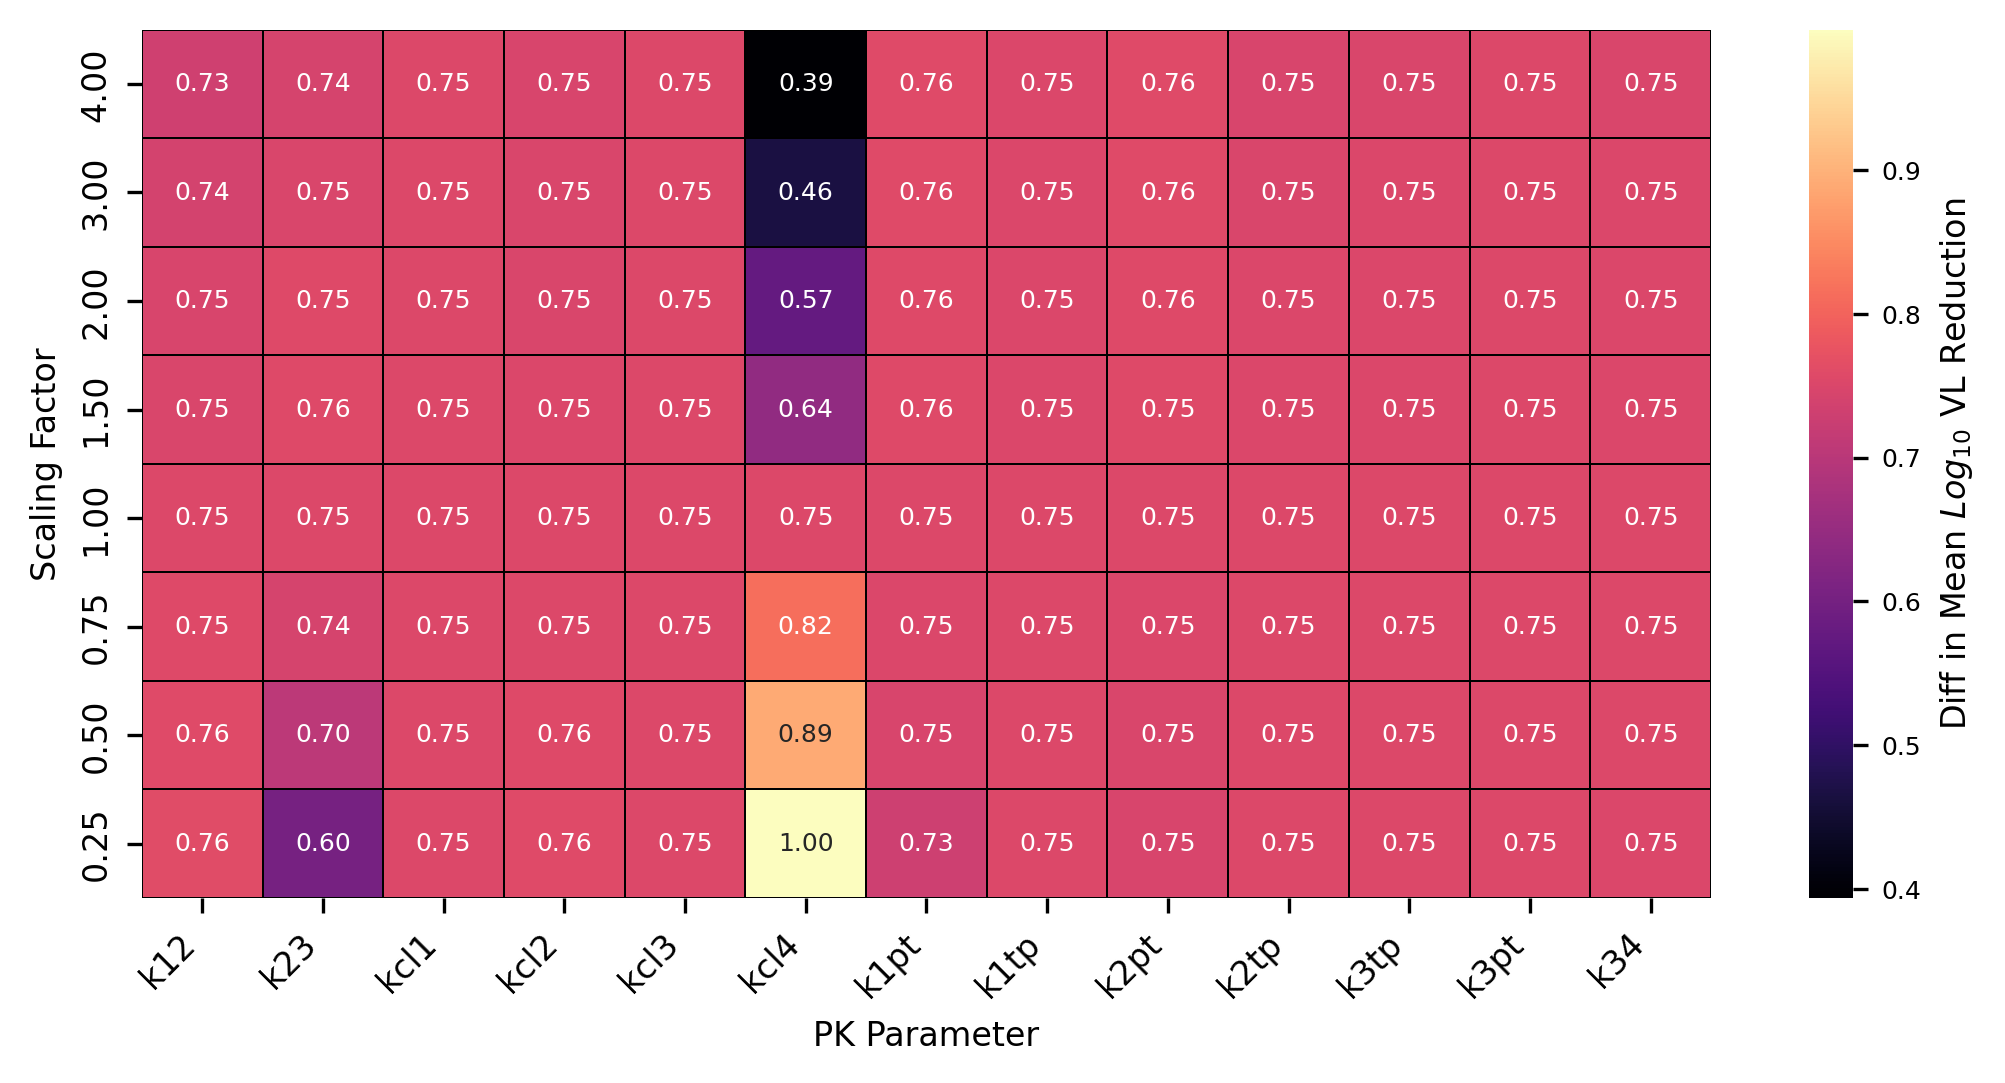

In [ ]:
df_vl_abs_sens = calculate_viral_load_absolute_sensitivity(target_patients_treated, treated_platcov_df, params_df_A4T)

Create plots of concentration and A4T epsilon over time for senstivity analysis for kcl4 over entire treatment arm

In [ ]:
# 1. Core Models & Setup
def pk_model_kcl4_only(t, y, custom_kcl4):
    """
    Modified ODE system specifically designed to accept kcl4 overrides.
    All other parameters are locked to their FIXED_PK base values.
    """
    A1, A1T, A2, A2T, A3, A3T, A4T = y

    ddt_A1 = FIXED_PK['k1tp']*A1T - (FIXED_PK['k1pt'] + FIXED_PK['k12'] + FIXED_PK['kcl1'])*A1
    ddt_A1T = FIXED_PK['k1pt']*A1 - FIXED_PK['k1tp']*A1T - FIXED_PK['k12']*A1T
    ddt_A2 = FIXED_PK['k12']*A1 + FIXED_PK['k2tp']*A2T - (FIXED_PK['k2pt'] + FIXED_PK['kcl2'] + FIXED_PK['k23'])*A2
    ddt_A2T = FIXED_PK['k2pt']*A2 + FIXED_PK['k12']*A1T - FIXED_PK['k23']*A2T - FIXED_PK['k2tp']*A2T
    ddt_A3 = FIXED_PK['k3tp']*A3T - (FIXED_PK['kcl3'] + FIXED_PK['k3pt'])*A3 + FIXED_PK['k23']*A2
    ddt_A3T = -FIXED_PK['k3tp']*A3T + FIXED_PK['k23']*A2T + FIXED_PK['k3pt']*A3 - FIXED_PK['k34']*A3T
    # Custom kcl4 is substituted here
    ddt_A4T = FIXED_PK['k34']*A3T - custom_kcl4*A4T

    return [ddt_A1, ddt_A1T, ddt_A2, ddt_A2T, ddt_A3, ddt_A3T, ddt_A4T]

In [ ]:
# 2. Optimized Cohort Simulation Engine
def simulate_kcl4_cohort_median(kcl4_val, patient_ids, param_A1, param_A2, param_A3, param_A4T):
    """
    Simulates the PK regimen once, then broadcasts PD calculations across
    the entire cohort to efficiently find the median efficacy.
    """
    # Extract all IC50s for the cohort as 1D NumPy arrays
    IC50_A1 = param_A1[param_A1['id'].isin(patient_ids)]['IC50_mode'].values
    IC50_A2 = param_A2[param_A2['id'].isin(patient_ids)]['IC50_mode'].values
    IC50_A3 = param_A3[param_A3['id'].isin(patient_ids)]['IC50_mode'].values
    IC50_A4T = param_A4T[param_A4T['id'].isin(patient_ids)]['IC50_mode'].values

    schedule = [(0.0, 200), (1.0, 100), (2.0, 100), (3.0, 100), (4.0, 100)]

    y0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
    t_out, y_out = [], []
    current_time = 0.0

    # Solve PK
    for t_event, dose_mg in schedule:
        y0[0] += dose_mg * PD_PARAMS['F']
        next_time = t_event + 1.0
        t_eval = np.linspace(current_time, next_time, 500)

        sol = solve_ivp(
            fun=pk_model_kcl4_only, t_span=(current_time, next_time), y0=y0, t_eval=t_eval,
            args=(kcl4_val,), method='LSODA'
        )

        t_out.append(sol.t[:-1])
        y_out.append(sol.y[:, :-1])
        y0 = sol.y[:, -1]
        current_time = next_time

    t_tail = np.linspace(current_time, current_time + 5.0, 1000)
    sol_tail = solve_ivp(
        fun=pk_model_kcl4_only, t_span=(current_time, current_time + 5.0),
        y0=y0, t_eval=t_tail, args=(kcl4_val,), method='LSODA'
    )
    t_out.append(sol_tail.t)
    y_out.append(sol_tail.y)

    t_sim = np.concatenate(t_out)
    y_sim = np.concatenate(y_out, axis=1)

    concs = {}
    median_epsilons = {}

    # Calculate concentrations and broadcast cohort epsilons for all 4 compartments
    compartment_map = [("A1", 0, IC50_A1), ("A2", 2, IC50_A2), ("A3", 4, IC50_A3), ("A4T", 6, IC50_A4T)]

    for comp, idx, ic50_array in compartment_map:
        amt = y_sim[idx]
        vol = PK_CONSTANTS[comp]["Volume"]
        mass = PK_CONSTANTS[comp]["MolMass"]

        concs[comp] = amt / vol

        # Micro-molar concentration (1D array: Time)
        Cc = amt / (vol * mass)

        eps_matrix = PD_PARAMS["Emax"] * (Cc[:, None]**PD_PARAMS["Hill"]) / ((Cc[:, None]**PD_PARAMS["Hill"]) + (ic50_array**PD_PARAMS["Hill"]))

        median_epsilons[comp] = np.median(eps_matrix, axis=1)

    return t_sim, concs, median_epsilons

In [ ]:

def plot_kcl4_dashboard_cohort(n_patients, title, t_b, c_b, e_b,
                            t_quarter, c_quarter, e_quarter,
                            t_quadruple, c_quadruple, e_quadruple):

    TINY_SIZE = 6
    SMALL_SIZE = 8
    MEDIUM_SIZE = 10
    BIGGER_SIZE = 12

    plt.rcParams.update({
        'font.size': SMALL_SIZE,
        'axes.labelsize': TINY_SIZE,
        'xtick.labelsize': TINY_SIZE,
        'ytick.labelsize': TINY_SIZE,
        'axes.titlesize': SMALL_SIZE,
        'legend.fontsize': TINY_SIZE,
        'figure.titlesize': SMALL_SIZE,
        'axes.titleweight': 'normal',
        'figure.titleweight': 'normal'
    })

    fig, axes = plt.subplots(1, 2, figsize=(3.5, 1.9), dpi=300)

    def format_xaxis(ax, show_bottom_x=True):
        ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
        ax.grid(True, alpha=0.2)
        if show_bottom_x:
            ax.set_xlabel("Time (Days)")
        else:
            ax.set_xlabel("")
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    panel_label_args = {'fontweight': 'bold', 'fontsize': SMALL_SIZE}
    lw = 0.7
    ms = 0.2

    ax0 = axes[0]
    ax0.plot(t_b, c_b["A4T"], color="black", linewidth=lw, marker='o', markersize=ms)
    ax0.plot(t_quarter, c_quarter["A4T"], color="red", linewidth=lw, marker='o', markersize=ms)
    ax0.plot(t_quadruple, c_quadruple["A4T"], color="blue", linewidth=lw, marker='o', markersize=ms)
    ax0.text(-0.25, 1.05, "I", transform=ax0.transAxes, **panel_label_args)
    ax0.set_ylabel("A4T (ng/mL)")
    ax0.set_yscale('log')
    format_xaxis(ax0, show_bottom_x=True)

    ax1 = axes[1]
    ax1.plot(t_b, e_b["A4T"], color="black", linewidth=lw, marker='o', markersize=ms)
    ax1.plot(t_quarter, e_quarter["A4T"], color="red", linewidth=lw, marker='o', markersize=ms)
    ax1.plot(t_quadruple, e_quadruple["A4T"], color="blue", linewidth=lw, marker='o', markersize=ms)
    ax1.text(-0.25, 1.05, "II", transform=ax1.transAxes, **panel_label_args)
    ax1.set_ylabel(r"A4T Efficacy ($\bar{\epsilon}$)")
    ax1.set_ylim(0, 1.05)
    format_xaxis(ax1, show_bottom_x=True)

    ax0.legend(["1x", "0.25x", "4x"],
             loc="lower right",
             framealpha=0.9,
             fontsize=TINY_SIZE)

    plt.tight_layout(pad=0.5)
    plt.show()
    plt.rcdefaults()


def run_kcl4_sensitivity_cohort(patient_ids, param_A1, param_A2, param_A3, param_A4T):

    kcl4_base = FIXED_PK['kcl4']
    kcl4_quarter = kcl4_base * 0.25
    kcl4_quadruple = kcl4_base * 4.00

    print(f"Executing Vectorized kcl4 Sensitivity Map across {len(patient_ids)} patients...")

    # 1. Simulate Baseline (1.0x)
    t_b, c_b, e_b = simulate_kcl4_cohort_median(kcl4_base, patient_ids, param_A1, param_A2, param_A3, param_A4T)

    # 2. Simulate Quarter (0.25x)
    t_quarter, c_quarter, e_quarter = simulate_kcl4_cohort_median(kcl4_quarter, patient_ids, param_A1, param_A2, param_A3, param_A4T)

    # 3. Simulate Quadruple (4.0x)
    t_quadruple, c_quadruple, e_quadruple = simulate_kcl4_cohort_median(kcl4_quadruple, patient_ids, param_A1, param_A2, param_A3, param_A4T)

    plot_kcl4_dashboard_cohort(
        len(patient_ids),
        "Target Parameter Sensitivity Analysis: $k_{cl4}$",
        t_b, c_b, e_b,
        t_quarter, c_quarter, e_quarter,
        t_quadruple, c_quadruple, e_quadruple
    )

Executing Vectorized kcl4 Sensitivity Map across 67 patients...


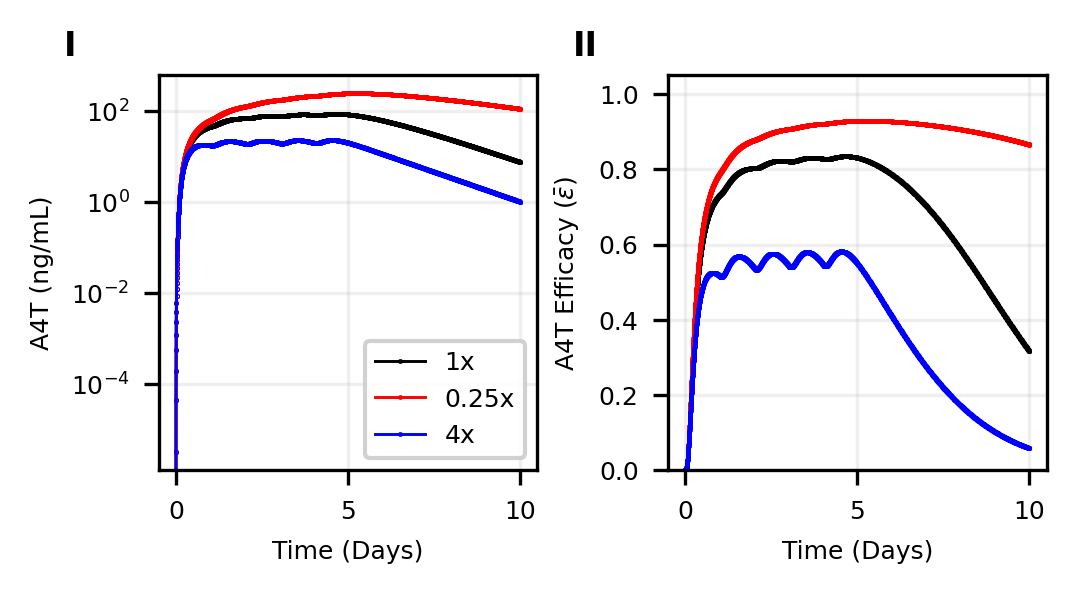

In [ ]:
run_kcl4_sensitivity_cohort(treated_patients, params_df_A1, params_df_A2, params_df_A3, params_df_A4T)

Concentration and efficacy plot for k23

In [ ]:

# 1. Core Models & Setup (k23 override)
def pk_model_k23_only(t, y, custom_k23):
    """
    Modified ODE system specifically designed to accept k23 overrides.
    All other parameters are locked to their FIXED_PK base values.
    """
    A1, A1T, A2, A2T, A3, A3T, A4T = y

    ddt_A1 = FIXED_PK['k1tp']*A1T - (FIXED_PK['k1pt'] + FIXED_PK['k12'] + FIXED_PK['kcl1'])*A1
    ddt_A1T = FIXED_PK['k1pt']*A1 - FIXED_PK['k1tp']*A1T - FIXED_PK['k12']*A1T

    # Custom k23 is substituted here
    ddt_A2 = FIXED_PK['k12']*A1 + FIXED_PK['k2tp']*A2T - (FIXED_PK['k2pt'] + FIXED_PK['kcl2'] + custom_k23)*A2
    ddt_A2T = FIXED_PK['k2pt']*A2 + FIXED_PK['k12']*A1T - custom_k23*A2T - FIXED_PK['k2tp']*A2T
    ddt_A3 = FIXED_PK['k3tp']*A3T - (FIXED_PK['kcl3'] + FIXED_PK['k3pt'])*A3 + custom_k23*A2
    ddt_A3T = -FIXED_PK['k3tp']*A3T + custom_k23*A2T + FIXED_PK['k3pt']*A3 - FIXED_PK['k34']*A3T
    ddt_A4T = FIXED_PK['k34']*A3T - FIXED_PK['kcl4']*A4T

    return [ddt_A1, ddt_A1T, ddt_A2, ddt_A2T, ddt_A3, ddt_A3T, ddt_A4T]

In [ ]:
# 2. Optimized Cohort Simulation Engine
def simulate_k23_cohort_median(k23_val, patient_ids, param_A1, param_A2, param_A3, param_A4T):
    """
    Simulates the PK regimen once, then broadcasts PD calculations across
    the entire cohort to efficiently find the median efficacy.
    """
    # Extract all IC50s for the cohort as 1D NumPy arrays
    IC50_A1 = param_A1[param_A1['id'].isin(patient_ids)]['IC50_mode'].values
    IC50_A2 = param_A2[param_A2['id'].isin(patient_ids)]['IC50_mode'].values
    IC50_A3 = param_A3[param_A3['id'].isin(patient_ids)]['IC50_mode'].values
    IC50_A4T = param_A4T[param_A4T['id'].isin(patient_ids)]['IC50_mode'].values

    schedule = [(0.0, 200), (1.0, 100), (2.0, 100), (3.0, 100), (4.0, 100)]

    y0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
    t_out, y_out = [], []
    current_time = 0.0

    for t_event, dose_mg in schedule:
        y0[0] += dose_mg * PD_PARAMS['F']
        next_time = t_event + 1.0
        t_eval = np.linspace(current_time, next_time, 500)

        sol = solve_ivp(
            fun=pk_model_k23_only, t_span=(current_time, next_time), y0=y0, t_eval=t_eval,
            args=(k23_val,), method='LSODA'
        )

        t_out.append(sol.t[:-1])
        y_out.append(sol.y[:, :-1])
        y0 = sol.y[:, -1]
        current_time = next_time

    t_tail = np.linspace(current_time, current_time + 5.0, 1000)
    sol_tail = solve_ivp(
        fun=pk_model_k23_only, t_span=(current_time, current_time + 5.0),
        y0=y0, t_eval=t_tail, args=(k23_val,), method='LSODA'
    )
    t_out.append(sol_tail.t)
    y_out.append(sol_tail.y)

    t_sim = np.concatenate(t_out)
    y_sim = np.concatenate(y_out, axis=1)

    concs = {}
    median_epsilons = {}

    # Calculate concentrations and broadcast cohort epsilons for all 4 compartments

    compartment_map = [("A1", 0, IC50_A1), ("A2", 2, IC50_A2), ("A3", 4, IC50_A3), ("A4T", 6, IC50_A4T)]

    for comp, idx, ic50_array in compartment_map:
        amt = y_sim[idx]
        vol = PK_CONSTANTS[comp]["Volume"]
        mass = PK_CONSTANTS[comp]["MolMass"]

        concs[comp] = amt / vol

        Cc = amt / (vol * mass)

        eps_matrix = PD_PARAMS["Emax"] * (Cc[:, None]**PD_PARAMS["Hill"]) / ((Cc[:, None]**PD_PARAMS["Hill"]) + (ic50_array**PD_PARAMS["Hill"]))

        median_epsilons[comp] = np.median(eps_matrix, axis=1)

    return t_sim, concs, median_epsilons

Create 2 panel figure for k23 sensitivity analysis

In [ ]:

def plot_k23_dashboard_cohort(n_patients, title, t_b, c_b, e_b,
                            t_quarter, c_quarter, e_quarter,
                            t_quadruple, c_quadruple, e_quadruple):

    TINY_SIZE = 6
    SMALL_SIZE = 8
    MEDIUM_SIZE = 10
    BIGGER_SIZE = 12

    plt.rcParams.update({
        'font.size': SMALL_SIZE,
        'axes.labelsize': TINY_SIZE,
        'xtick.labelsize': TINY_SIZE,
        'ytick.labelsize': TINY_SIZE,
        'axes.titlesize': SMALL_SIZE,
        'legend.fontsize': TINY_SIZE,
        'figure.titlesize': SMALL_SIZE,
        'axes.titleweight': 'normal',
        'figure.titleweight': 'normal'
    })

    fig, axes = plt.subplots(1, 2, figsize=(3.5, 1.9), dpi=300)

    def format_xaxis(ax, show_bottom_x=True):
        ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
        ax.grid(True, alpha=0.2)
        if show_bottom_x:
            ax.set_xlabel("Time (Days)")
        else:
            ax.set_xlabel("")
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    panel_label_args = {'fontweight': 'bold', 'fontsize': SMALL_SIZE}
    lw = 0.7
    ms = 0.2

    ax0 = axes[0]
    ax0.plot(t_b, c_b["A4T"], color="black", linewidth=lw, marker='o', markersize=ms)
    ax0.plot(t_quarter, c_quarter["A4T"], color="red", linestyle="--", linewidth=lw, marker='o', markersize=ms)
    ax0.plot(t_quadruple, c_quadruple["A4T"], color="blue", linestyle=":", linewidth=lw, marker='o', markersize=ms)
    ax0.text(-0.25, 1.05, "I", transform=ax0.transAxes, **panel_label_args)
    ax0.set_ylabel("A4T (ng/mL)")
    ax0.set_yscale('log')
    format_xaxis(ax0, show_bottom_x=True)

    ax1 = axes[1]
    ax1.plot(t_b, e_b["A4T"], color="black", linewidth=lw, marker='o', markersize=ms)
    ax1.plot(t_quarter, e_quarter["A4T"], color="red", linestyle="--", linewidth=lw, marker='o', markersize=ms)
    ax1.plot(t_quadruple, e_quadruple["A4T"], color="blue", linestyle=":", linewidth=lw, marker='o', markersize=ms)
    ax1.text(-0.25, 1.05, "II", transform=ax1.transAxes, **panel_label_args)
    ax1.set_ylabel(r"A4T Efficacy $\bar{\epsilon}$")
    ax1.set_ylim(0, 1.05)
    format_xaxis(ax1, show_bottom_x=True)

    ax0.legend(["1x", "0.25x", "4x"],
             loc="lower right",
             framealpha=0.9,
             fontsize=TINY_SIZE)

    plt.tight_layout(pad=0.5)
    plt.show()
    plt.rcdefaults()


In [ ]:
def run_k23_sensitivity_cohort(patient_ids, param_A1, param_A2, param_A3, param_A4T):

    k23_base = FIXED_PK['k23']
    k23_quarter = k23_base * 0.25
    k23_quadruple = k23_base * 4.00

    print(f"Executing Vectorized k23 Sensitivity Map across {len(patient_ids)} patients...")

    # 1. Simulate Baseline (1.0x)
    t_b, c_b, e_b = simulate_k23_cohort_median(k23_base, patient_ids, param_A1, param_A2, param_A3, param_A4T)

    # 2. Simulate Quarter (0.25x)
    t_quarter, c_quarter, e_quarter = simulate_k23_cohort_median(k23_quarter, patient_ids, param_A1, param_A2, param_A3, param_A4T)

    # 3. Simulate Quadruple (4.0x)
    t_quadruple, c_quadruple, e_quadruple = simulate_k23_cohort_median(k23_quadruple, patient_ids, param_A1, param_A2, param_A3, param_A4T)

    plot_k23_dashboard_cohort(
        len(patient_ids),
        r"Target Parameter Sensitivity Analysis: $k_{23}$",
        t_b, c_b, e_b,
        t_quarter, c_quarter, e_quarter,
        t_quadruple, c_quadruple, e_quadruple
    )

Executing Vectorized k23 Sensitivity Map across 67 patients...


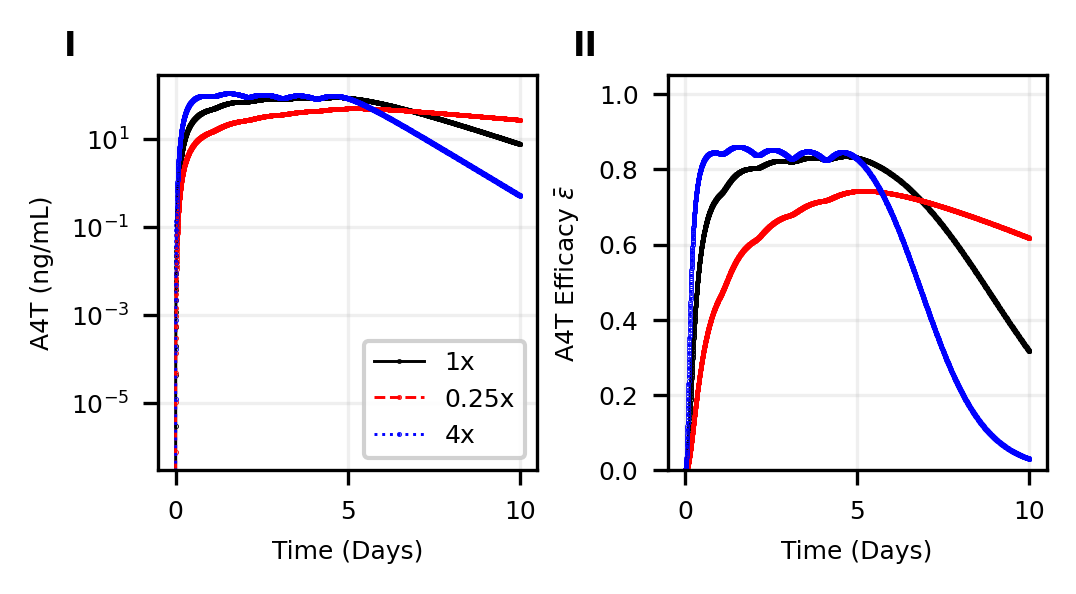

In [ ]:
run_k23_sensitivity_cohort(treated_patients, params_df_A1, params_df_A2, params_df_A3, params_df_A4T)

Plot mean viral load reduction for treatment arm in senstivity analysis

Simulating Viral Load kcl4 sensitivity for 67 treated patients. Please wait...
Simulating Viral Load for 95 untreated patients. Please wait...


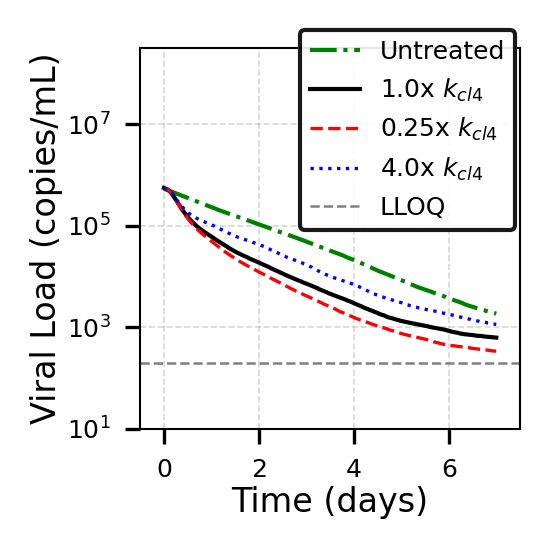

In [ ]:

def simulate_patient_adjusted_kcl4(patient_id, target_cpt, data_df, param_df, custom_kcl4):
    """
    Executes piecewise integration of the viral dynamic model for a single patient
    using the overridden kcl4 parameter from the sensitivity analysis.
    """
    p_row = param_df[param_df['id'] == patient_id].iloc[0]
    params = {
        'beta': 10 ** p_row['log10beta_mode'], 'pi': 10 ** p_row['log10pi_mode'],
        'rho': 10 ** p_row['log10rho_mode'], 'phi': 10 ** p_row['log10phi_mode'],
        'delta': p_row['delta_mode'], 'm': p_row['m_mode'], 'tau': p_row['tau_mode'],
        'tzero': p_row['tzero_mode'], 'Vzero': p_row['Vzero_mode'], 'IC50': p_row['IC50_mode']
    }

    pt_data = data_df[data_df['ID'] == patient_id].sort_values(by='time').copy()

    y0 = [0, 0, 0, 0, 0, 0, 0, 1e7, 0, 0, 0, params['Vzero']]
    t_start = -params['tzero']

    t_out, y_out = [], []
    current_time = t_start
    first_record = pt_data.iloc[0]

    active_inputs = {
        'treatment': first_record['treatment']
    }

    def vd_model_adjusted(t, y, target, p, inputs):
        A1, A1T, A2, A2T, A3, A3T, A4T, T, R, E, I, V = y
        treatment = inputs['treatment']
        beta, pi, rho, phi, delta, m, tau, IC50 = p['beta'], p['pi'], p['rho'], p['phi'], p['delta'], p['m'], p['tau'], p['IC50']

        # Expanded PK ODE with kcl4 override
        ddt_A1 = FIXED_PK['k1tp']*A1T - (FIXED_PK['k1pt'] + FIXED_PK['k12'] + FIXED_PK['kcl1'])*A1
        ddt_A1T = FIXED_PK['k1pt']*A1 - FIXED_PK['k1tp']*A1T - FIXED_PK['k12']*A1T
        ddt_A2 = FIXED_PK['k12']*A1 + FIXED_PK['k2tp']*A2T - (FIXED_PK['k2pt'] + FIXED_PK['kcl2'] + FIXED_PK['k23'])*A2
        ddt_A2T = FIXED_PK['k2pt']*A2 + FIXED_PK['k12']*A1T - FIXED_PK['k23']*A2T - FIXED_PK['k2tp']*A2T
        ddt_A3 = FIXED_PK['k3tp']*A3T - (FIXED_PK['kcl3'] + FIXED_PK['k3pt'])*A3 + FIXED_PK['k23']*A2
        ddt_A3T = -FIXED_PK['k3tp']*A3T + FIXED_PK['k23']*A2T + FIXED_PK['k3pt']*A3 - FIXED_PK['k34']*A3T
        ddt_A4T = FIXED_PK['k34']*A3T - custom_kcl4*A4T

        Cc = 0
        if target == "A4T":
            Cc = A4T / (PK_CONSTANTS["A4T"]["Volume"] * PK_CONSTANTS["A4T"]["MolMass"])

        epsilon = 0
        if treatment != 0 and Cc > 0:
            epsilon = PD_PARAMS['Emax'] * (Cc**PD_PARAMS['Hill']) / ((Cc**PD_PARAMS['Hill']) + (IC50**PD_PARAMS['Hill']))

        eps = m if t > tau else 0
        ddt_T = -beta * T * V - phi * I * T + rho * R
        ddt_R = phi * I * T - rho * R
        ddt_E = beta * T * V - PD_PARAMS['k'] * E
        ddt_I = PD_PARAMS['k'] * E - delta * I - eps * I
        temp = pi * (1 - epsilon) * I - PD_PARAMS['c'] * V if I >= 1 else -PD_PARAMS['c'] * V
        ddt_V = temp

        return [ddt_A1, ddt_A1T, ddt_A2, ddt_A2T, ddt_A3, ddt_A3T, ddt_A4T, ddt_T, ddt_R, ddt_E, ddt_I, ddt_V]

    for idx, row in pt_data.iterrows():
        t_event = row['time']
        if t_event > current_time:
            t_eval = np.linspace(current_time, t_event, max(50, int((t_event - current_time) * 100)))
            sol = solve_ivp(
                fun=vd_model_adjusted, t_span=(current_time, t_event), y0=y0,
                t_eval=t_eval, args=(target_cpt, params, active_inputs), method='LSODA', max_step=0.1
            )
            t_out.append(sol.t)
            y_out.append(sol.y)
            y0 = sol.y[:, -1]
            current_time = t_event

        dose_mg = row['Amnt_mg']
        if pd.notna(dose_mg) and dose_mg > 0:
            y0[0] += dose_mg * PD_PARAMS['F']

        if pd.notna(row['treatment']):
            active_inputs['treatment'] = row['treatment']

    t_final = current_time + 8.0
    sol = solve_ivp(
        fun=vd_model_adjusted, t_span=(current_time, t_final), y0=y0,
        t_eval=np.linspace(current_time, t_final, 500),
        args=(target_cpt, params, active_inputs), method='LSODA'
    )
    t_out.append(sol.t)
    y_out.append(sol.y)

    t_sim = np.concatenate(t_out)
    y_sim = np.concatenate(y_out, axis=1)

    V_raw = y_sim[11, :]

    # Apply LLOQ of 200. Impute values below 200 as 100 (half LLOQ).
    V_imputed = np.where(V_raw < 200.0, 100.0, V_raw)
    log10V_sim = np.log10(V_imputed)

    return t_sim, log10V_sim

def simulate_kcl4_viral_load(patient_id, data_df, param_df, custom_kcl4):
    """
    Wrapper to simulate the viral dynamic model for a single patient
    using a specific kcl4 override while locking all other PK parameters.
    """
    t_sim, log10V_sim = simulate_patient_adjusted_kcl4(
        patient_id=patient_id,
        target_cpt="A4T",
        data_df=data_df,
        param_df=param_df,
        custom_kcl4=custom_kcl4
    )
    return t_sim, log10V_sim


def generate_kcl4_vl_sensitivity_plot_4factor(vd_df, param_A4T):

    TINY_SIZE = 6
    SMALL_SIZE = 8
    MEDIUM_SIZE = 10
    BIGGER_SIZE = 12

    # Isolate treated Platcov patients
    treated_platcov_df = vd_df[(vd_df['Study'] == 'Platcov') & (vd_df['treatment_cov'] == 1)].copy()
    patient_ids = treated_platcov_df['ID'].unique()

    # Isolate untreated Platcov patients
    untreated_platcov_df = vd_df[(vd_df['Study'] == 'Platcov') & (vd_df['treatment_cov'] == 0)].copy()
    untreated_patient_ids = untreated_platcov_df['ID'].unique()

    kcl4_base = FIXED_PK['kcl4']
    kcl4_quarter = kcl4_base * 0.25
    kcl4_quadruple = kcl4_base * 4.00

    t_common = np.linspace(0, 7, 500)

    pop_vl_base = []
    pop_vl_quarter = []
    pop_vl_quadruple = []
    pop_vl_untreated = []

    print(f"Simulating Viral Load kcl4 sensitivity for {len(patient_ids)} treated patients. Please wait...")

    for pid in patient_ids:
        pt_data = treated_platcov_df[treated_platcov_df['ID'] == pid]
        doses = pt_data[pt_data['Amnt_mg'] > 0]
        t_zero = doses['time'].min() if not doses.empty else pt_data['time'].min()

        # Run 3 scenarios
        t_b, v_b = simulate_kcl4_viral_load(pid, treated_platcov_df, param_A4T, kcl4_base)
        t_q, v_q = simulate_kcl4_viral_load(pid, treated_platcov_df, param_A4T, kcl4_quarter)
        t_quad, v_quad = simulate_kcl4_viral_load(pid, treated_platcov_df, param_A4T, kcl4_quadruple)

        pop_vl_base.append(np.interp(t_common, t_b - t_zero, v_b, left=np.nan, right=np.nan))
        pop_vl_quarter.append(np.interp(t_common, t_q - t_zero, v_q, left=np.nan, right=np.nan))
        pop_vl_quadruple.append(np.interp(t_common, t_quad - t_zero, v_quad, left=np.nan, right=np.nan))

    print(f"Simulating Viral Load for {len(untreated_patient_ids)} untreated patients. Please wait...")

    for pid in untreated_patient_ids:
        pt_data = untreated_platcov_df[untreated_platcov_df['ID'] == pid]
        doses = pt_data[pt_data['Amnt_mg'] > 0]
        t_zero = doses['time'].min() if not doses.empty else pt_data['time'].min()

        t_u, v_u = simulate_kcl4_viral_load(pid, untreated_platcov_df, param_A4T, kcl4_base)
        pop_vl_untreated.append(np.interp(t_common, t_u - t_zero, v_u, left=np.nan, right=np.nan))

    # Population means
    mean_vl_base = np.nanmean(np.array(pop_vl_base), axis=0)
    mean_vl_quarter = np.nanmean(np.array(pop_vl_quarter), axis=0)
    mean_vl_quadruple = np.nanmean(np.array(pop_vl_quadruple), axis=0)
    mean_vl_untreated = np.nanmean(np.array(pop_vl_untreated), axis=0)


    plt.rcParams.update({
        'font.size': SMALL_SIZE,
        'axes.labelsize': SMALL_SIZE,
        'xtick.labelsize': TINY_SIZE,
        'ytick.labelsize': TINY_SIZE,
        'legend.fontsize': TINY_SIZE,
        'axes.linewidth': 0.5
    })

    fig, ax = plt.subplots(figsize=(1.7, 1.7), dpi=300)

    lw_main = 1.0
    lw_secondary = 0.8

    ax.plot(t_common, 10**mean_vl_untreated, color="green", linewidth=lw_main,
            linestyle="-.", label="Untreated")

    ax.plot(t_common, 10**mean_vl_base, color="black", linewidth=lw_main,
            label="1.0x $k_{cl4}$")
    ax.plot(t_common, 10**mean_vl_quarter, color="red", linewidth=lw_secondary,
            linestyle="--", label="0.25x $k_{cl4}$")
    ax.plot(t_common, 10**mean_vl_quadruple, color="blue", linewidth=lw_secondary,
            linestyle=":", label="4.0x $k_{cl4}$")

    ax.axhline(y=200, color='grey', linestyle='--', linewidth=0.6,
               label='LLOQ')

    ax.set_yscale('log')
    ax.set_ylim(10**1, 10**8.5)
    ax.set_xlim(-0.5, 7.5)

    ax.set_xlabel("Time (days)", labelpad=1)
    ax.set_ylabel("Viral Load (copies/mL)", labelpad=1)

    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5)

    ax.legend(
        loc='upper right',
        bbox_to_anchor=(1.02, 1.08),
        frameon=True,
        edgecolor='black',
        framealpha=0.9,
        fontsize=TINY_SIZE
    )

    plt.tight_layout(pad=0.3)
    plt.show()

    plt.rcdefaults()

In [ ]:
generate_kcl4_vl_sensitivity_plot_4factor(vd_df, params_df_A4T)

Viral load over time sensitivity analysis for k23

In [ ]:

def simulate_patient_adjusted_k23(patient_id, target_cpt, data_df, param_df, custom_k23):
    """
    Executes piecewise integration of the viral dynamic model for a single patient
    using the overridden k23 parameter from the sensitivity analysis.
    """
    p_row = param_df[param_df['id'] == patient_id].iloc[0]
    params = {
        'beta': 10 ** p_row['log10beta_mode'], 'pi': 10 ** p_row['log10pi_mode'],
        'rho': 10 ** p_row['log10rho_mode'], 'phi': 10 ** p_row['log10phi_mode'],
        'delta': p_row['delta_mode'], 'm': p_row['m_mode'], 'tau': p_row['tau_mode'],
        'tzero': p_row['tzero_mode'], 'Vzero': p_row['Vzero_mode'], 'IC50': p_row['IC50_mode']
    }

    pt_data = data_df[data_df['ID'] == patient_id].sort_values(by='time').copy()

    y0 = [0, 0, 0, 0, 0, 0, 0, 1e7, 0, 0, 0, params['Vzero']]
    t_start = -params['tzero']

    t_out, y_out = [], []
    current_time = t_start
    first_record = pt_data.iloc[0]

    active_inputs = {
        'treatment': first_record['treatment']
    }

    def vd_model_adjusted(t, y, target, p, inputs):
        A1, A1T, A2, A2T, A3, A3T, A4T, T, R, E, I, V = y
        treatment = inputs['treatment']
        beta, pi, rho, phi, delta, m, tau, IC50 = p['beta'], p['pi'], p['rho'], p['phi'], p['delta'], p['m'], p['tau'], p['IC50']

        # Expanded PK ODE with k23 override
        ddt_A1 = FIXED_PK['k1tp']*A1T - (FIXED_PK['k1pt'] + FIXED_PK['k12'] + FIXED_PK['kcl1'])*A1
        ddt_A1T = FIXED_PK['k1pt']*A1 - FIXED_PK['k1tp']*A1T - FIXED_PK['k12']*A1T

        # Custom k23 is substituted here
        ddt_A2 = FIXED_PK['k12']*A1 + FIXED_PK['k2tp']*A2T - (FIXED_PK['k2pt'] + FIXED_PK['kcl2'] + custom_k23)*A2
        ddt_A2T = FIXED_PK['k2pt']*A2 + FIXED_PK['k12']*A1T - custom_k23*A2T - FIXED_PK['k2tp']*A2T
        ddt_A3 = FIXED_PK['k3tp']*A3T - (FIXED_PK['kcl3'] + FIXED_PK['k3pt'])*A3 + custom_k23*A2
        ddt_A3T = -FIXED_PK['k3tp']*A3T + custom_k23*A2T + FIXED_PK['k3pt']*A3 - FIXED_PK['k34']*A3T

        ddt_A4T = FIXED_PK['k34']*A3T - FIXED_PK['kcl4']*A4T

        Cc = 0
        if target == "A4T":
            Cc = A4T / (PK_CONSTANTS["A4T"]["Volume"] * PK_CONSTANTS["A4T"]["MolMass"])

        epsilon = 0
        if treatment != 0 and Cc > 0:
            epsilon = PD_PARAMS['Emax'] * (Cc**PD_PARAMS['Hill']) / ((Cc**PD_PARAMS['Hill']) + (IC50**PD_PARAMS['Hill']))

        eps = m if t > tau else 0
        ddt_T = -beta * T * V - phi * I * T + rho * R
        ddt_R = phi * I * T - rho * R
        ddt_E = beta * T * V - PD_PARAMS['k'] * E
        ddt_I = PD_PARAMS['k'] * E - delta * I - eps * I
        temp = pi * (1 - epsilon) * I - PD_PARAMS['c'] * V if I >= 1 else -PD_PARAMS['c'] * V
        ddt_V = temp

        return [ddt_A1, ddt_A1T, ddt_A2, ddt_A2T, ddt_A3, ddt_A3T, ddt_A4T, ddt_T, ddt_R, ddt_E, ddt_I, ddt_V]

    for idx, row in pt_data.iterrows():
        t_event = row['time']
        if t_event > current_time:
            t_eval = np.linspace(current_time, t_event, max(50, int((t_event - current_time) * 100)))
            sol = solve_ivp(
                fun=vd_model_adjusted, t_span=(current_time, t_event), y0=y0,
                t_eval=t_eval, args=(target_cpt, params, active_inputs), method='LSODA', max_step=0.1
            )
            t_out.append(sol.t)
            y_out.append(sol.y)
            y0 = sol.y[:, -1]
            current_time = t_event

        dose_mg = row['Amnt_mg']
        if pd.notna(dose_mg) and dose_mg > 0:
            y0[0] += dose_mg * PD_PARAMS['F']

        if pd.notna(row['treatment']):
            active_inputs['treatment'] = row['treatment']

    t_final = current_time + 8.0
    sol = solve_ivp(
        fun=vd_model_adjusted, t_span=(current_time, t_final), y0=y0,
        t_eval=np.linspace(current_time, t_final, 500),
        args=(target_cpt, params, active_inputs), method='LSODA'
    )
    t_out.append(sol.t)
    y_out.append(sol.y)

    t_sim = np.concatenate(t_out)
    y_sim = np.concatenate(y_out, axis=1)

    V_raw = y_sim[11, :]

    V_imputed = np.where(V_raw < 200.0, 100.0, V_raw)
    log10V_sim = np.log10(V_imputed)

    return t_sim, log10V_sim


def simulate_k23_viral_load(patient_id, data_df, param_df, custom_k23):
    """
    Wrapper to simulate the viral dynamic model for a single patient
    using a specific k23 override while locking all other PK parameters.
    """
    t_sim, log10V_sim = simulate_patient_adjusted_k23(
        patient_id=patient_id,
        target_cpt="A4T",
        data_df=data_df,
        param_df=param_df,
        custom_k23=custom_k23
    )
    return t_sim, log10V_sim


def generate_k23_vl_sensitivity_plot_4factor(vd_df, param_A4T):

    TINY_SIZE = 6
    SMALL_SIZE = 8
    MEDIUM_SIZE = 10
    BIGGER_SIZE = 12

    # Isolate treated Platcov patients
    treated_platcov_df = vd_df[(vd_df['Study'] == 'Platcov') & (vd_df['treatment_cov'] == 1)].copy()
    patient_ids = treated_platcov_df['ID'].unique()

    # Isolate untreated Platcov patients
    untreated_platcov_df = vd_df[(vd_df['Study'] == 'Platcov') & (vd_df['treatment_cov'] == 0)].copy()
    untreated_patient_ids = untreated_platcov_df['ID'].unique()

    k23_base = FIXED_PK['k23']
    k23_quarter = k23_base * 0.25
    k23_quadruple = k23_base * 4.00

    t_common = np.linspace(0, 7, 500)

    pop_vl_base = []
    pop_vl_quarter = []
    pop_vl_quadruple = []
    pop_vl_untreated = []

    print(f"Simulating Viral Load k23 sensitivity for {len(patient_ids)} treated patients. Please wait...")

    for pid in patient_ids:
        pt_data = treated_platcov_df[treated_platcov_df['ID'] == pid]
        doses = pt_data[pt_data['Amnt_mg'] > 0]
        t_zero = doses['time'].min() if not doses.empty else pt_data['time'].min()

        # Run 3 scenarios
        t_b, v_b = simulate_k23_viral_load(pid, treated_platcov_df, param_A4T, k23_base)
        t_q, v_q = simulate_k23_viral_load(pid, treated_platcov_df, param_A4T, k23_quarter)
        t_quad, v_quad = simulate_k23_viral_load(pid, treated_platcov_df, param_A4T, k23_quadruple)

        pop_vl_base.append(np.interp(t_common, t_b - t_zero, v_b, left=np.nan, right=np.nan))
        pop_vl_quarter.append(np.interp(t_common, t_q - t_zero, v_q, left=np.nan, right=np.nan))
        pop_vl_quadruple.append(np.interp(t_common, t_quad - t_zero, v_quad, left=np.nan, right=np.nan))

    print(f"Simulating Viral Load for {len(untreated_patient_ids)} untreated patients. Please wait...")

    for pid in untreated_patient_ids:
        pt_data = untreated_platcov_df[untreated_platcov_df['ID'] == pid]
        doses = pt_data[pt_data['Amnt_mg'] > 0]
        t_zero = doses['time'].min() if not doses.empty else pt_data['time'].min()

        t_u, v_u = simulate_k23_viral_load(pid, untreated_platcov_df, param_A4T, k23_base)
        pop_vl_untreated.append(np.interp(t_common, t_u - t_zero, v_u, left=np.nan, right=np.nan))

    # Population means
    mean_vl_base = np.nanmean(np.array(pop_vl_base), axis=0)
    mean_vl_quarter = np.nanmean(np.array(pop_vl_quarter), axis=0)
    mean_vl_quadruple = np.nanmean(np.array(pop_vl_quadruple), axis=0)
    mean_vl_untreated = np.nanmean(np.array(pop_vl_untreated), axis=0)


    plt.rcParams.update({
        'font.size': SMALL_SIZE,
        'axes.labelsize': SMALL_SIZE,
        'xtick.labelsize': TINY_SIZE,
        'ytick.labelsize': TINY_SIZE,
        'legend.fontsize': TINY_SIZE,
        'axes.linewidth': 0.5
    })

    fig, ax = plt.subplots(figsize=(1.7, 1.7), dpi=300)

    lw_main = 1.0
    lw_secondary = 0.8

    ax.plot(t_common, 10**mean_vl_untreated, color="green", linewidth=lw_main,
            linestyle="-.", label="Untreated")

    ax.plot(t_common, 10**mean_vl_base, color="black", linewidth=lw_main,
            label="1.0x $k_{23}$")
    ax.plot(t_common, 10**mean_vl_quarter, color="red", linewidth=lw_secondary,
            linestyle="--", label="0.25x $k_{23}$")
    ax.plot(t_common, 10**mean_vl_quadruple, color="blue", linewidth=lw_secondary,
            linestyle=":", label="4.0x $k_{23}$")

    ax.axhline(y=200, color='grey', linestyle='--', linewidth=0.6,
               label='LLOQ')

    ax.set_yscale('log')
    ax.set_ylim(10**1, 10**8.5)
    ax.set_xlim(-0.5, 7.5)

    ax.set_xlabel("Time (days)", labelpad=1)
    ax.set_ylabel("Viral Load (copies/mL)", labelpad=1)

    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5)

    ax.legend(
        loc='upper right',
        bbox_to_anchor=(1.02, 1.08),
        frameon=True,
        edgecolor='black',
        framealpha=0.9,
        fontsize=TINY_SIZE
    )

    plt.tight_layout(pad=0.3)
    plt.show()
    plt.rcdefaults()

Simulating Viral Load k23 sensitivity for 67 treated patients. Please wait...
Simulating Viral Load for 95 untreated patients. Please wait...


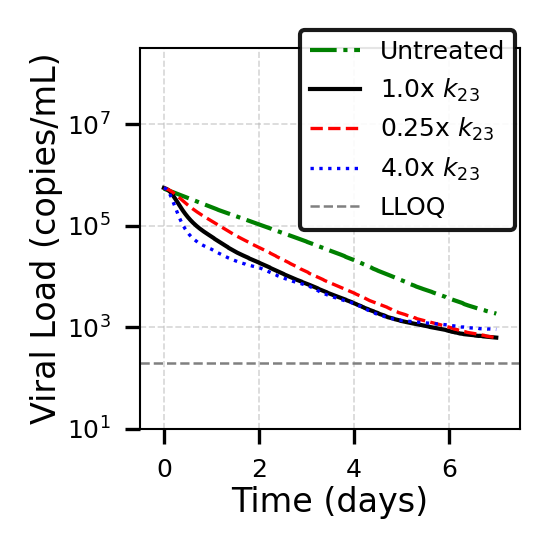

In [ ]:
generate_k23_vl_sensitivity_plot_4factor(vd_df, params_df_A4T)